In [1]:
# Plot country level exposure to surface o3

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import matplotlib.cm as mpl_cm
from utils.utils import adjust_longitude
from utils.utils import autosize_figure
from utils.utils import land_filter

In [3]:
# === Concatenate ensemble members ===
def merge_ensembles(VAR_DIR, VAR, scenario, dates, time_mean=False, land_mask=False):
    """ land_filter=True allows for the land filter function to remove the ocean """
    ens = []

    for ens_num in range(1, 11):
        da = xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_{scenario}_{ens_num:02d}_{dates}.nc")
        if time_mean is True:
            da = da.mean("year")
        ens.append(da)

    new_da = xr.concat(ens, dim=xr.DataArray(np.arange(1, len(ens)+1), dims="ensemble", name="ensemble"))

    if land_mask is True:
        print("Filtering ocean")
        new_da = land_filter(new_da)

    return new_da

In [4]:
# === Path config ===
DIR = "/glade/work/awells/air_quality/CESM/ozone/exposure/"
VAR = "OSDMA8_country_population_weighted_exposure"

# === Main loop ===
arise_o3 = merge_ensembles(DIR, VAR, "ARISE", "2035-2068")
ssp245_o3 = merge_ensembles(DIR, VAR, "SSP245", "2020-2068")

In [6]:
MASK_DIR = "/glade/work/awells/air_quality/BMR/masks/country/"
country_mask = xr.open_dataarray(f"{MASK_DIR}GBD_Country_Masks_0.10_popgrid_newlabels.nc")

In [11]:
# Create DataArray filled with NaNs
country_exposure_ssp245 = xr.DataArray(
    np.full((len(country_mask.lat), len(country_mask.lon)), np.nan),
    coords={"lat": country_mask.lat.values, "lon": country_mask.lon.values},
    dims=["lat", "lon"]
)

ssp245_mean = ssp245_o3.mean("ensemble")

# Loop over countries, add the mortality for each country and apply using country mask
for i in range(204):
    mask = country_mask.isel(country=i)
    country = mask["country"]
    ssp245_country = ssp245_mean.sel(country=country.values) # adds all years
    country_exposure_ssp245 = country_exposure_ssp245.where(mask == 0, ssp245_country)

In [12]:
# Create DataArray filled with NaNs
country_exposure_arise = xr.DataArray(
    np.full((len(country_mask.lat), len(country_mask.lon)), np.nan),
    coords={"lat": country_mask.lat.values, "lon": country_mask.lon.values},
    dims=["lat", "lon"]
)

arise_mean = arise_o3.mean("ensemble")

# Loop over countries, add the mortality for each country and apply using country mask
for i in range(204):
    mask = country_mask.isel(country=i)
    country = mask["country"]
    arise_country = arise_mean.sel(country=country.values) # adds all years
    country_exposure_arise = country_exposure_arise.where(mask == 0, arise_country)

In [13]:
diff_30s = (country_exposure_arise - country_exposure_ssp245).sel(year=slice(2035, 2039)).mean("year")
diff_40s = (country_exposure_arise - country_exposure_ssp245).sel(year=slice(2040, 2049)).mean("year")
diff_50s = (country_exposure_arise - country_exposure_ssp245).sel(year=slice(2050, 2059)).mean("year")
diff_60s = (country_exposure_arise - country_exposure_ssp245).sel(year=slice(2060, 2068)).mean("year")

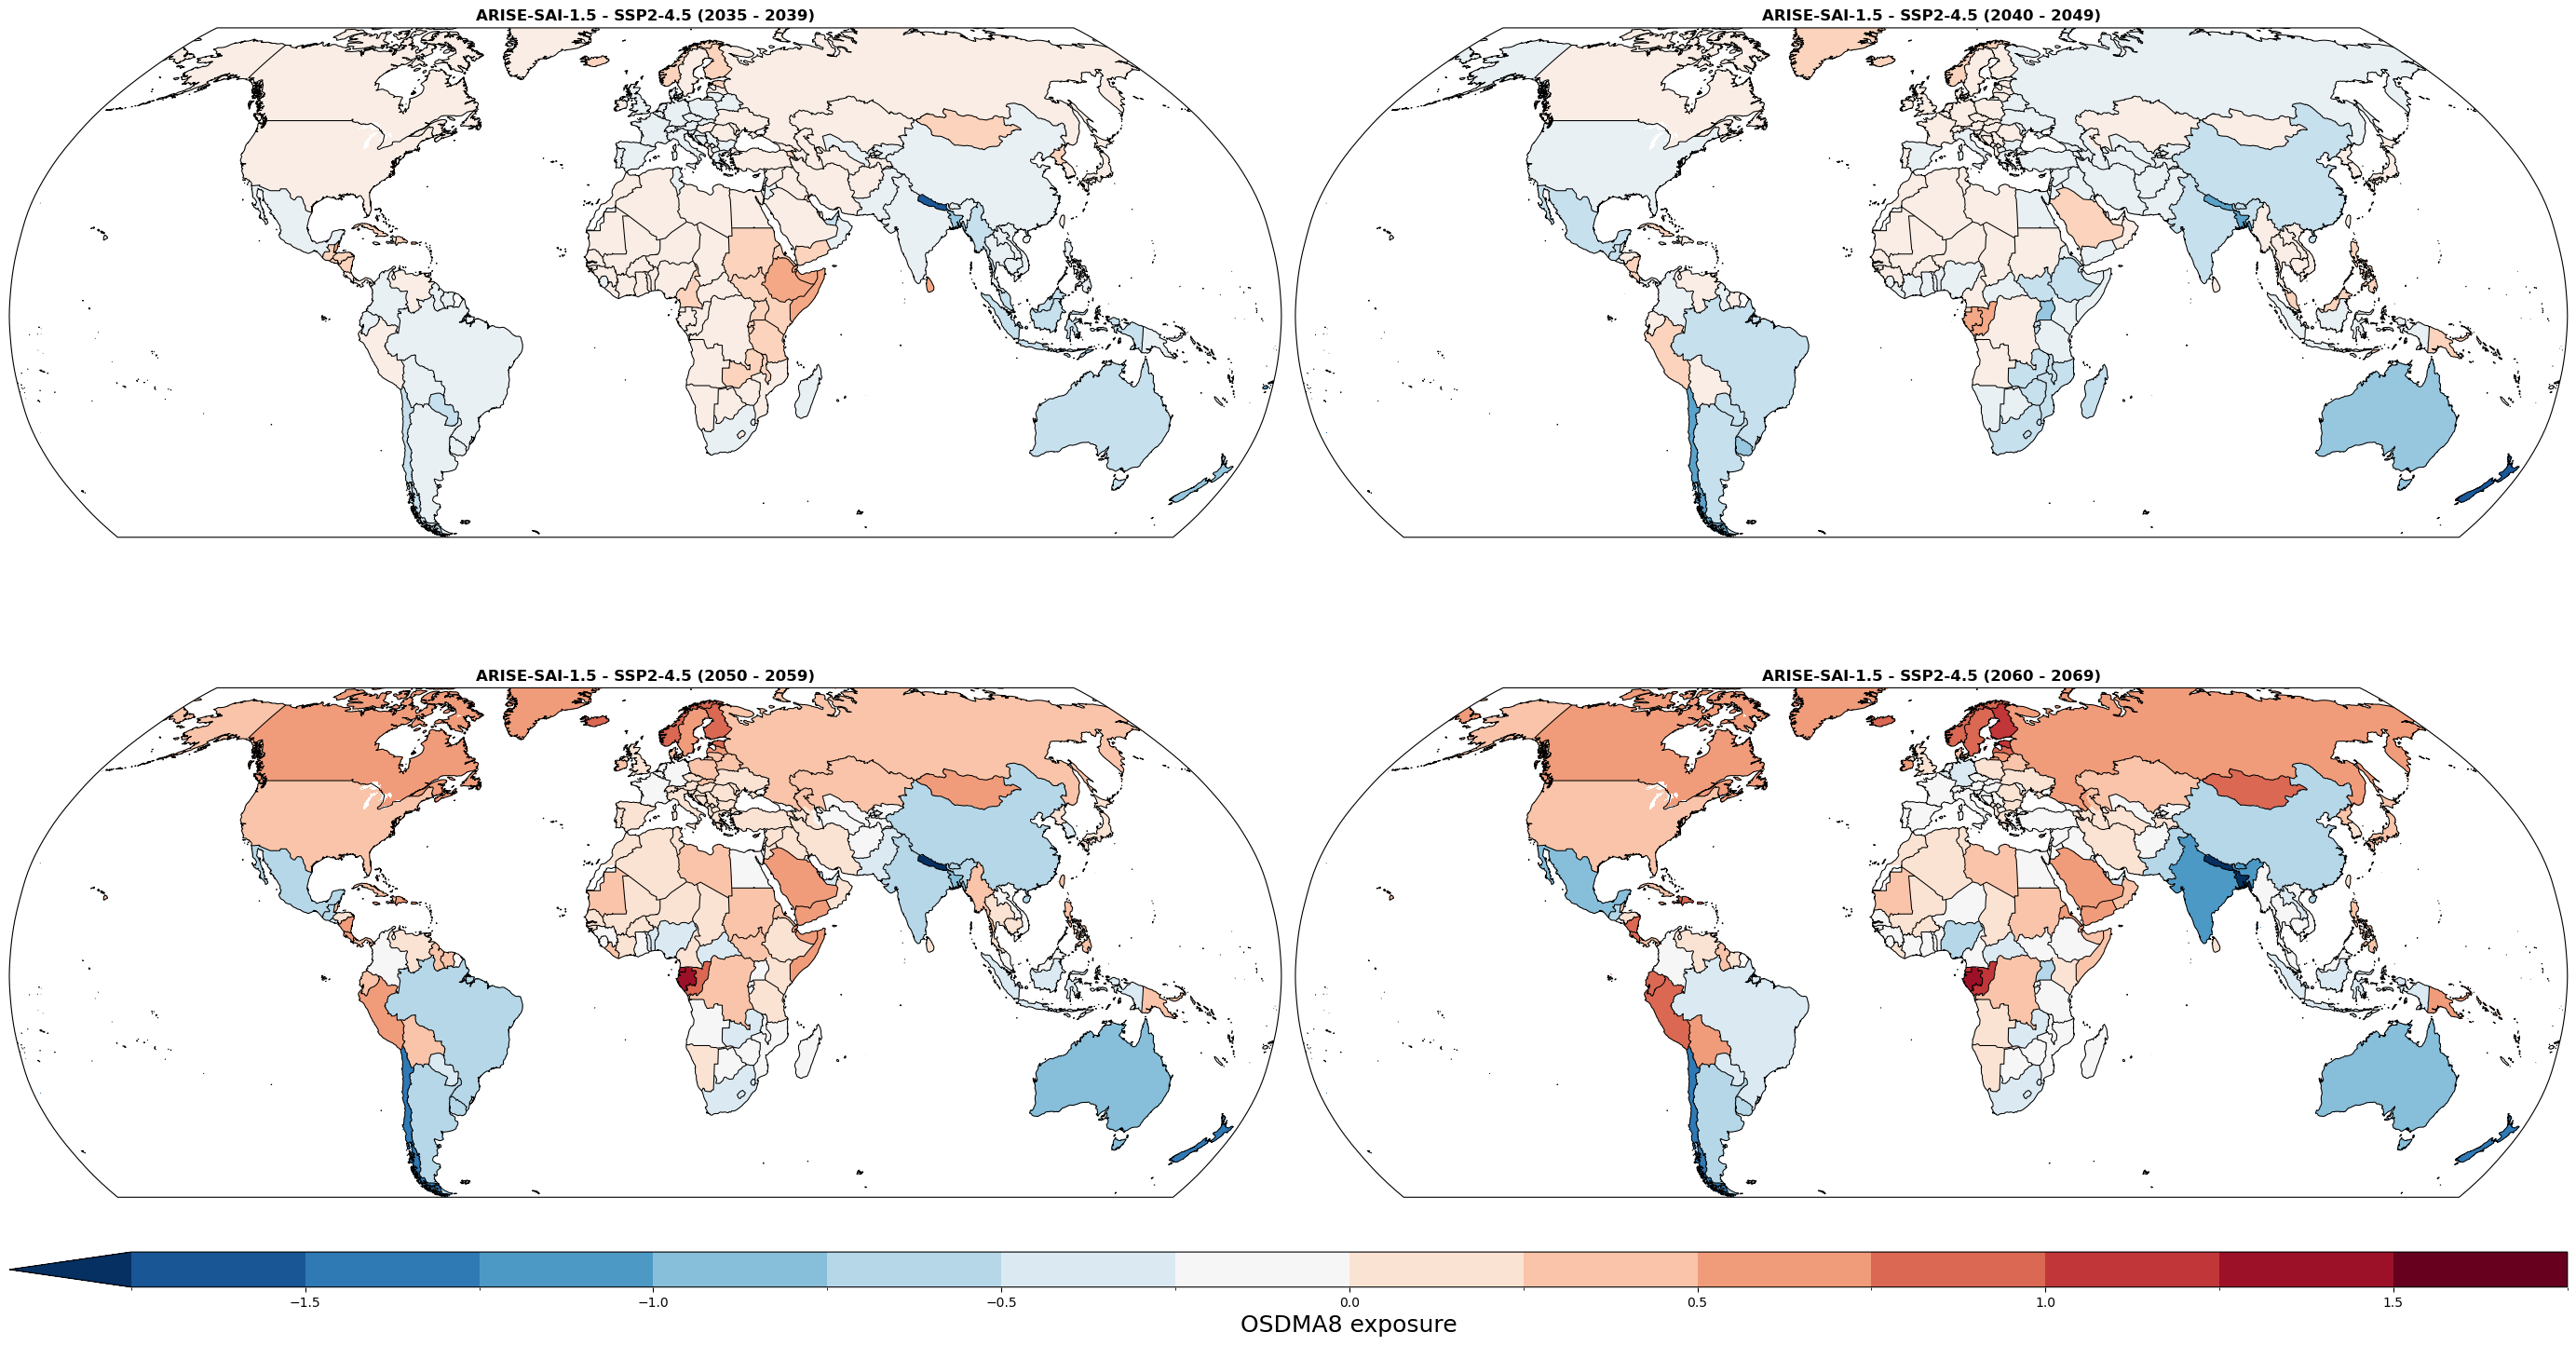

In [14]:
fig = plt.figure(figsize=autosize_figure(2, 2, scale_factor=1.6, xscale_factor=1.3))
gs = GridSpec(3, 2, height_ratios=[20, 20, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('Reds')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')

levels = [-1.75, -1.5, -1.25, -1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75]

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = diff_30s.plot(transform=crs, levels=levels,
                   add_colorbar=False, subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2035 - 2039)", fontweight='bold')

# Second panel
ax = fig.add_subplot(gs[0, 1], projection=projection, frameon=True)
cb = diff_40s.plot(transform=crs, levels=levels,
                   add_colorbar=False, subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2040 - 2049)", fontweight='bold')

# Third panel
ax = fig.add_subplot(gs[1, 0], projection=projection, frameon=True)
cb = diff_50s.plot(transform=crs, levels=levels,
                   add_colorbar=False, subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2050 - 2059)", fontweight='bold')

# Fourth panel
ax = fig.add_subplot(gs[1, 1], projection=projection, frameon=True)
cb = diff_60s.plot(transform=crs, levels=levels,
                   add_colorbar=False, subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2060 - 2069)", fontweight='bold')

# Colorbar
cax = fig.add_subplot(gs[2, :])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label('OSDMA8 exposure', fontsize=18)

plt.tight_layout()